# **1. PIPELINE (Flujo de Trabajo) / RECOLECCIÓN DE DATOS**

In [1]:
# Librerias para manipulacion de Data y Gráficas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#Preparación de datos y configuración de pipeline para Machine Learning con scikit-learn
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import validation_curve
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

#models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
#for classification
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier

# Balanceo
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN

# Otras
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
# Importar el dataset directamente de Drive

# Reemplaza con el ID real de tu archivo en Drive
file_id = '15E5nCnq603GKhqsbPOpvUR6LVTmWH4xK'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Cargar el dataset
df = pd.read_csv(url)
df

# https://drive.google.com/file/d/15E5nCnq603GKhqsbPOpvUR6LVTmWH4xK/view?usp=sharing

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,27,26296.0,Bachelor,Urban,37.4,211.4,Sedan,0.0,314.8,10.0,...,9.9,6.6,8.9,5.1,7.8,9.3,1,High,162.5,37.5
49996,39,35476.0,Master,Suburban,30.5,158.3,Sedan,2.8,278.5,7.5,...,8.7,6.0,9.4,3.8,2.0,8.8,0,High,129.6,11.9
49997,30,20862.0,Master,Suburban,37.5,295.2,Sedan,0.0,358.4,7.7,...,7.3,6.6,4.5,5.2,1.3,5.9,0,High,218.3,52.8
49998,68,14694.0,Bachelor,Rural,40.3,256.5,Sedan,6.0,306.1,2.7,...,8.3,3.8,6.6,4.7,5.4,9.3,0,High,216.0,50.3


In [3]:
#Entender y conocer el dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

# **2. PIPELINE / ANÁLISIS EXPLORATORIO DE DATOS (EDA) + LIMPIEZA + FEATURE ENGINEERING**

2.1 Análisis general del Dataset

In [4]:
# Estadística Descriptiva
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,44.996080,14.110844,21.00,33.00,45.00,57.00,69.00
annual_income,50000.0,44311.869380,26109.170784,5104.00,25617.75,37891.00,56051.25,250000.00
daily_commute_km,50000.0,35.169358,14.736042,5.00,25.00,35.10,45.20,97.90
weekly_travel_distance_km,50000.0,228.727200,101.147254,25.00,157.70,224.10,294.50,732.30
vehicle_age_years,50000.0,6.012842,2.947132,0.00,3.90,6.00,8.00,20.00
fuel_expense_per_month,50000.0,295.169608,130.178552,-99.70,205.20,294.80,383.00,862.00
charging_station_accessibility,49500.0,5.892947,2.152186,1.00,4.40,5.90,7.40,10.00
nearest_charging_station_km,50000.0,7.132370,4.801992,0.50,3.00,6.90,10.70,28.50
home_charging_available,50000.0,0.649760,0.477050,0.00,0.00,1.00,1.00,1.00
electricity_cost_per_kwh,50000.0,0.215359,0.077914,0.08,0.15,0.22,0.28,0.35


2.2 Duplicados

In [5]:
# 1. Verificar si existen filas duplicadas
cantidad_duplicados = df.duplicated().sum()
print(f'Cantidad de filas duplicadas: {cantidad_duplicados}')

# 2. Si existen, puedes eliminarlos y mantener la primera aparición
if cantidad_duplicados > 0:
    df = df.drop_duplicates()
    print('Los duplicados han sido eliminados.')
else:
    print('No se encontraron duplicados para eliminar.')

# 3. Validar el nuevo tamaño del dataset
print(f'Nuevo tamaño del dataset: {df.shape}')

Cantidad de filas duplicadas: 0
No se encontraron duplicados para eliminar.
Nuevo tamaño del dataset: (50000, 23)


## 2.3 Valores Nulos y Faltantes (Ausentes): Missing Values

In [6]:
# Verificar cantidad de nulos por feature o columna
df.isnull().sum()

,0
age,0
annual_income,0
education_level,500
city_type,0
daily_commute_km,0
weekly_travel_distance_km,0
current_vehicle_type,0
vehicle_age_years,0
fuel_expense_per_month,0
charging_station_accessibility,500


In [7]:
# Eliminar filas con valores nulos
df = df.dropna()

# Verificar el nuevo tamaño del dataset
print(f'Nuevo tamaño del dataset tras eliminar nulos: {df.shape}')
# Confirmar que ya no hay nulos
print(df.isnull().sum())

Nuevo tamaño del dataset tras eliminar nulos: (48511, 23)
age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              0
vehicle_age_years                 0
fuel_expense_per_month            0
charging_station_accessibility    0
nearest_charging_station_km       0
home_charging_available           0
electricity_cost_per_kwh          0
environmental_awareness_score     0
government_incentive_awareness    0
technology_affinity_score         0
range_anxiety_score               0
battery_replacement_concern       0
ev_knowledge_score                0
previous_ev_experience            0
ev_adoption_likelihood            0
monthly_energy_consumption_kwh    0
monthly_charging_cost             0
dtype: int64


## 2.4 Data Visualization

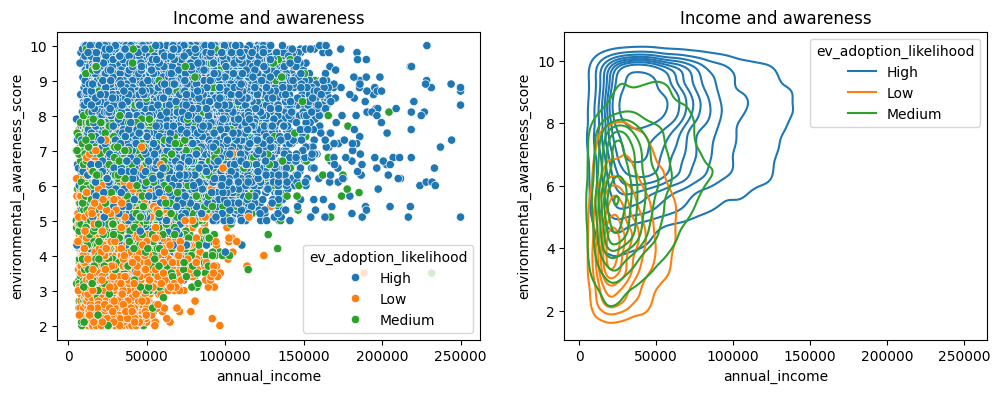

In [8]:
plt.figure(figsize=(12,4)) # 12 x 4 pulg (con un DPI de 100 sería 1.200 x 400 pixeles)
# DPI (Dots Per Inch o puntos por pulgada)

plt.subplot(1,2,1)
plt.title('Income and awareness')
sns.scatterplot(x=df['annual_income'],y=df['environmental_awareness_score'],hue=df['ev_adoption_likelihood']);

plt.subplot(1,2,2)
plt.title('Income and awareness')
sns.kdeplot(x=df['annual_income'],y=df['environmental_awareness_score'],hue=df['ev_adoption_likelihood']);

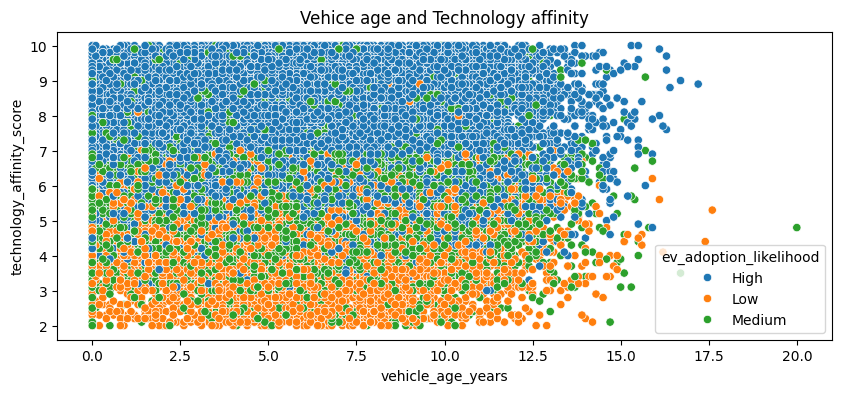

In [ ]:
plt.figure(figsize=(10,4))
plt.title('Vehicle age and Technology affinity')
sns.scatterplot(x=df['vehicle_age_years'],y=df['technology_affinity_score'],hue=df['ev_adoption_likelihood']);

**Distribución de Datos**


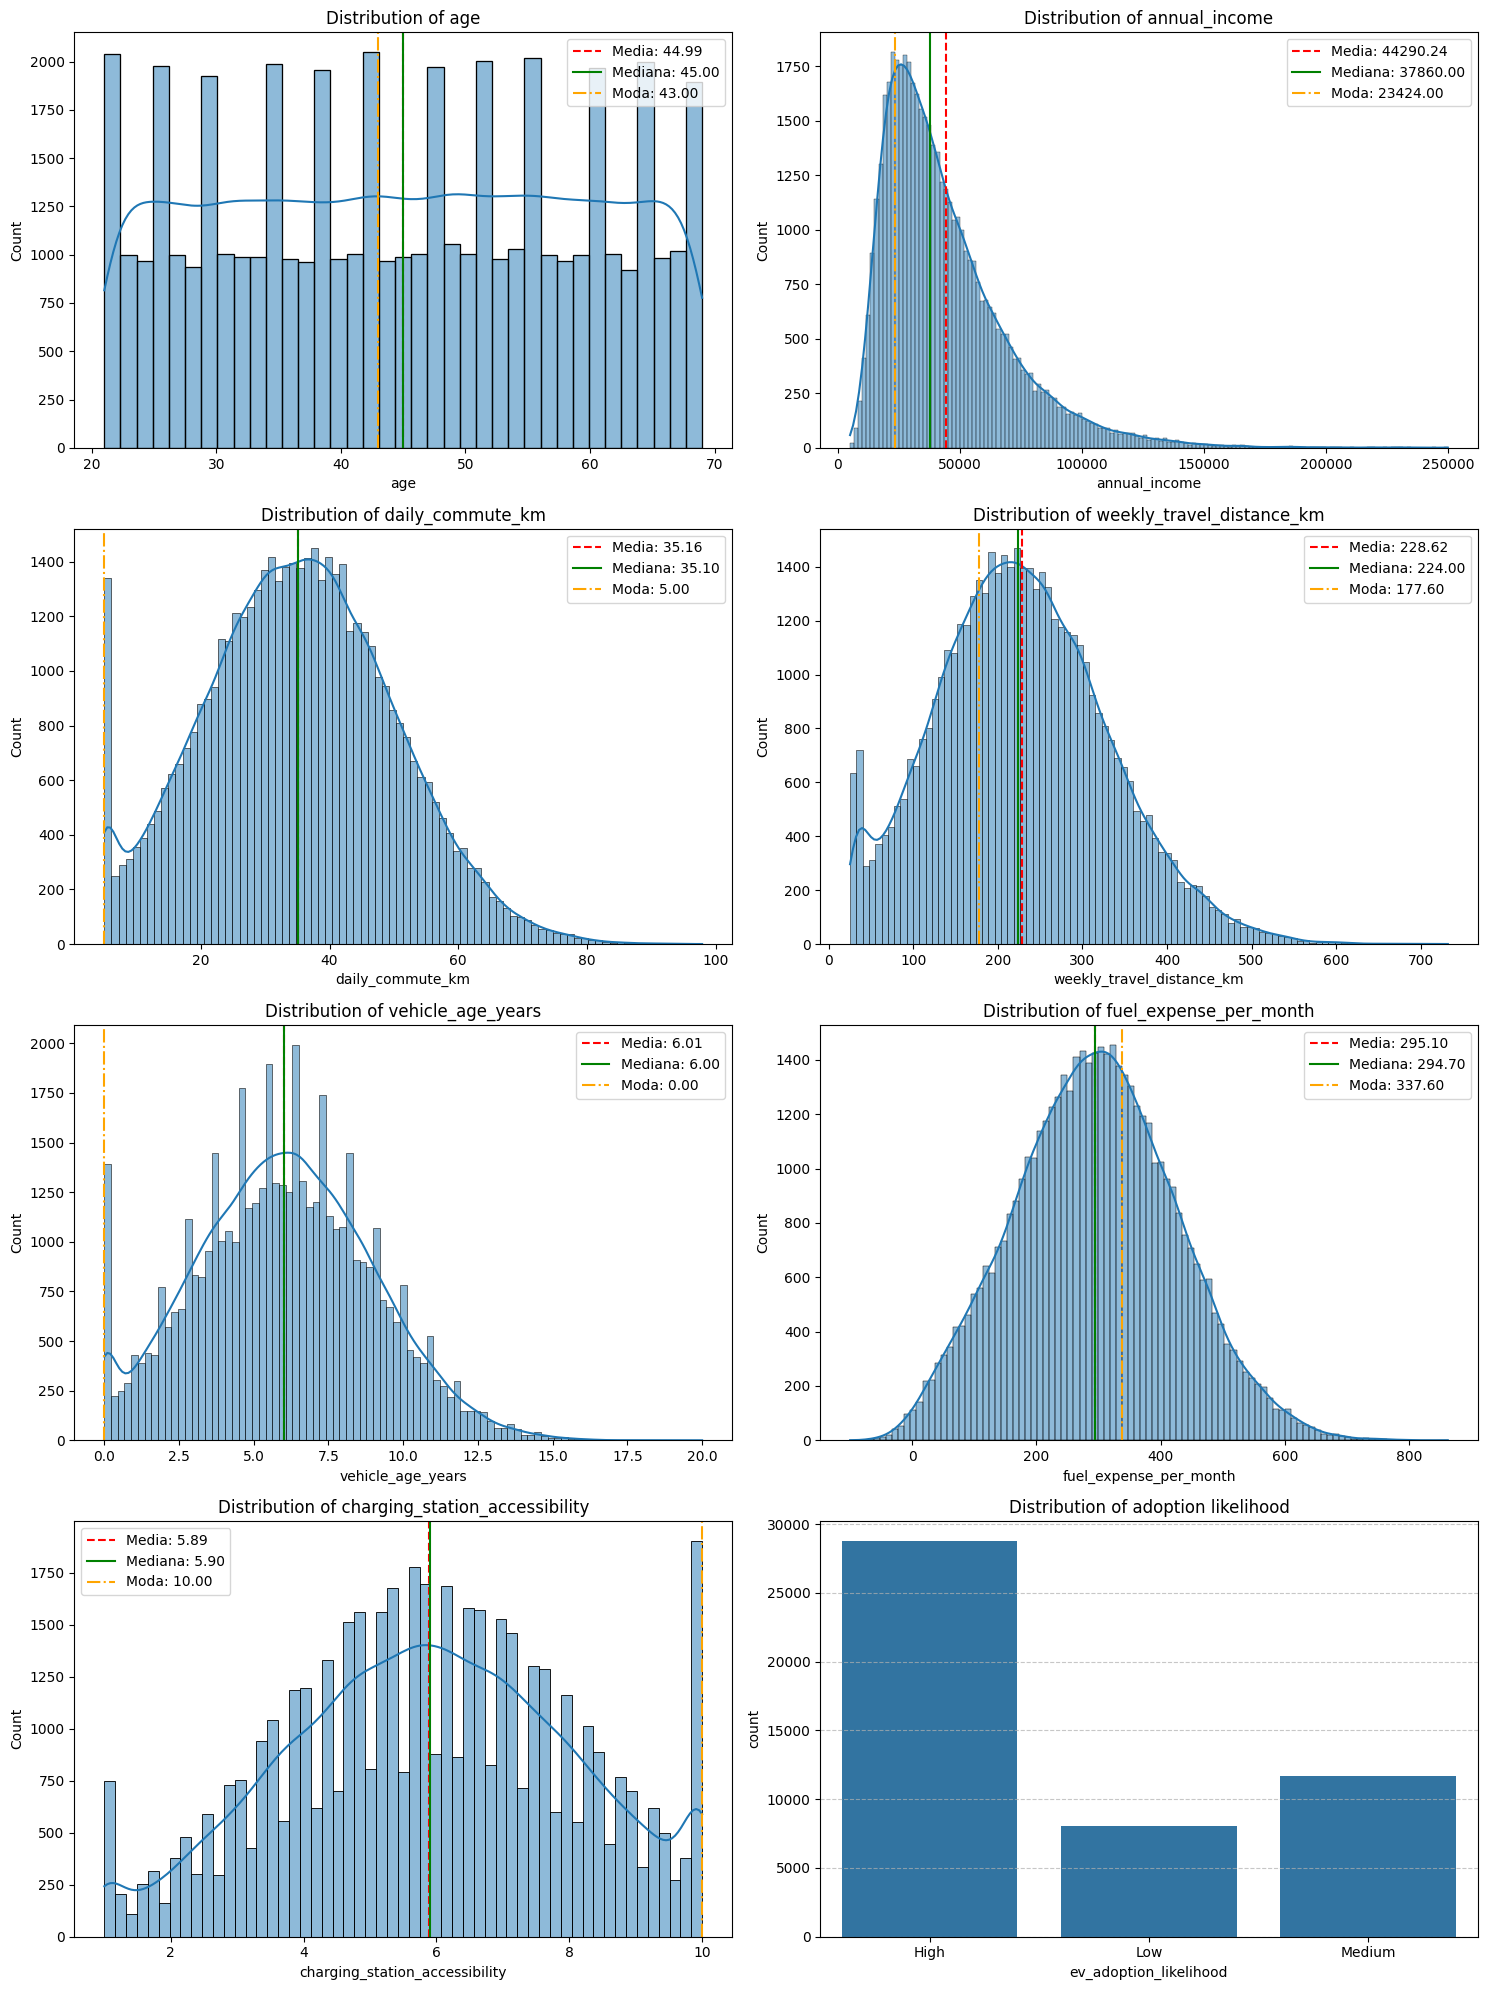

In [9]:
# Seleccionar columnas numéricas
numerical_df = df.select_dtypes(include=['number'])
num_vars = list(numerical_df.columns[:7]) # Limitamos a las primeras 7 para el ejemplo o ajustamos grid

# Configurar la cuadrícula de subplots (4 filas, 2 columnas para 8 espacios)
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

# Graficar variables numéricas
for i, var in enumerate(num_vars):
    sns.histplot(data=df, x=var, kde=True, ax=axes[i])

    # Calcular medidas de tendencia central
    mean = df[var].mean()
    median = df[var].median()
    mode = df[var].mode()[0]

    # Añadir líneas de referencia
    axes[i].axvline(mean, color='red', linestyle='--', label=f'Media: {mean:.2f}')
    axes[i].axvline(median, color='green', linestyle='-', label=f'Mediana: {median:.2f}')
    axes[i].axvline(mode, color='orange', linestyle='-.', label=f'Moda: {mode:.2f}')

    axes[i].set_title(f'Distribution of {var}')
    axes[i].legend()

# Graficar la columna categórica (ahora numérica) en la posición 7
sns.countplot(data=df, x='ev_adoption_likelihood', ax=axes[7])
axes[7].set_title('Distribution of adoption likelihood')
axes[7].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Crear el pairplot con colores según la variable "Rain"
sns.pairplot(df, hue='ev_adoption_likelihood')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

###**Diagrama de Cajas y Bigotes o Boxplot**

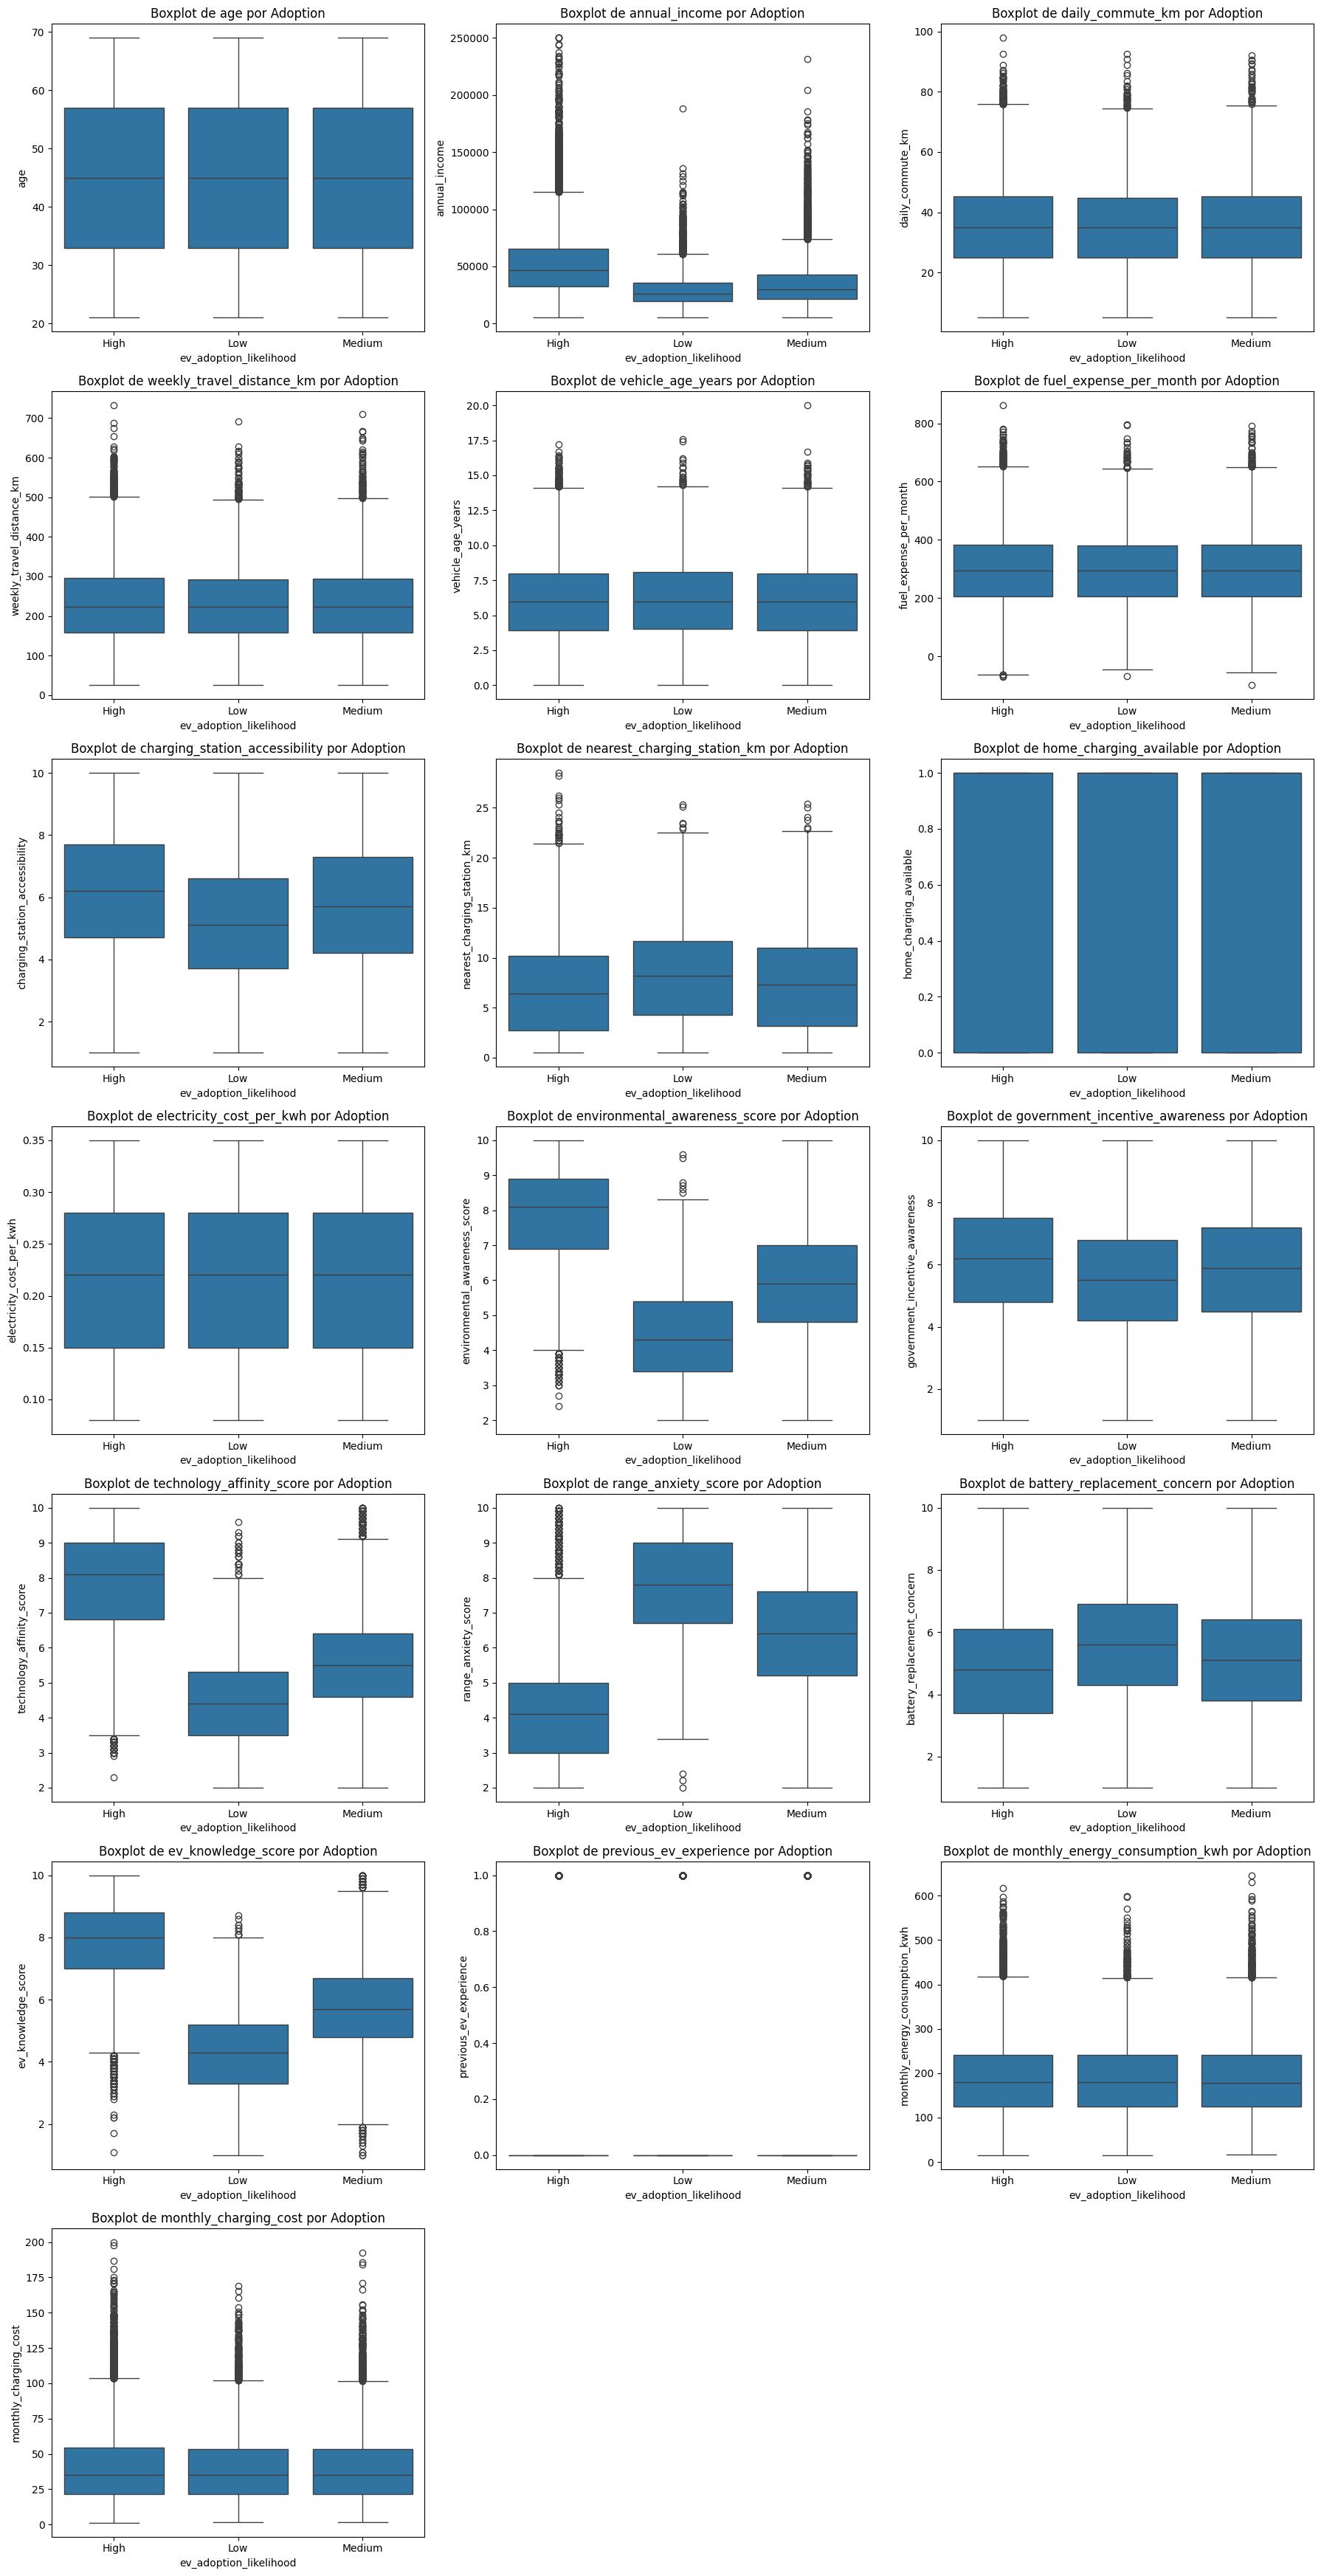

In [ ]:
# 1. Seleccionar columnas numéricas excluyendo explícitamente la variable objetivo
cols_to_plot = [col for col in df.select_dtypes(include=['number']).columns if col != 'ev_adoption_likelihood']

# 2. Configurar el tamaño de la figura y la cuadrícula dinámica
n_cols = 3
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x='ev_adoption_likelihood', y=col, data=df)
    # Swarmplot se mantiene comentado por eficiencia en datasets grandes
    # sns.swarmplot(x='ev_adoption_likelihood', y=col, data=df, color='black', size=1, alpha=0.3)
    plt.title(f'Boxplot de {col} por Adoption')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Calcular métricas de asimetría y curtosis
numerical_cols = df.select_dtypes(include=['number']).columns
stats = df[numerical_cols].agg(['skew', 'kurtosis']).T
print("Estadísticas de Asimetría y Curtosis:\n", stats)

Estadísticas de Asimetría y Curtosis:
                                     skew  kurtosis
age                            -0.007507 -1.192912
annual_income                   1.656328  4.412044
daily_commute_km                0.126933 -0.237714
weekly_travel_distance_km       0.318055  0.000471
vehicle_age_years               0.123374 -0.261383
fuel_expense_per_month          0.104380 -0.194990
charging_station_accessibility -0.070715 -0.576384
nearest_charging_station_km     0.340439 -0.660040
home_charging_available        -0.630591 -1.602420
electricity_cost_per_kwh       -0.010494 -1.184195
environmental_awareness_score  -0.339006 -0.746891
government_incentive_awareness -0.085597 -0.380165
technology_affinity_score      -0.187605 -0.989295
range_anxiety_score             0.425322 -0.703115
battery_replacement_concern     0.084663 -0.371133
ev_knowledge_score             -0.369592 -0.558997
previous_ev_experience          1.511074  0.283356
monthly_energy_consumption_kwh  0.539467  0

### Codificación de Variables Categóricas (One-Hot Encoding)

Ahora codificaremos las variables categóricas restantes (`education_level`, `city_type`, `current_vehicle_type`) para que todo el dataset sea numérico.

In [10]:
# 1. Identificar columnas categóricas
columnas_categoricas = ['education_level', 'city_type', 'current_vehicle_type']

# 2. Aplicar One-Hot Encoding si las columnas aún existen
if any(col in df.columns for col in columnas_categoricas):
    df = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)
    print("Codificación One-Hot realizada.")

# 3. Convertir TODAS las columnas booleanas a enteros (0 y 1)
# Esto asegura la conversión incluso si la codificación se hizo en una ejecución previa
cols_bool = df.select_dtypes(include=['bool']).columns
if len(cols_bool) > 0:
    df[cols_bool] = df[cols_bool].astype(int)
    print(f"Se han convertido {len(cols_bool)} columnas booleanas a numéricas.")

# Mostrar el estado final del dataset
print(f'Tamaño final del dataset: {df.shape}')
display(df.head())
print("Tipos de datos finales:")
print(df.dtypes.value_counts())

Codificación One-Hot realizada.
Se han convertido 8 columnas booleanas a numéricas.
Tamaño final del dataset: (48511, 28)


,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,...,monthly_energy_consumption_kwh,monthly_charging_cost,education_level_High School,education_level_Master,education_level_PhD,city_type_Suburban,city_type_Urban,current_vehicle_type_SUV,current_vehicle_type_Sedan,current_vehicle_type_Truck
0,56,23019.0,39.8,205.7,6.1,317.1,3.9,9.5,1,0.14,...,199.8,28.5,1,0,0,1,0,0,0,0
1,46,26440.0,34.6,218.4,4.4,290.0,4.5,11.6,1,0.16,...,139.8,22.9,1,0,0,1,0,0,1,0
2,46,57167.0,30.5,177.7,0.4,201.4,6.3,6.4,1,0.24,...,158.0,38.5,0,0,1,1,0,0,1,0
3,23,15841.0,44.6,325.9,0.0,407.3,5.2,8.8,0,0.22,...,207.0,45.0,0,1,0,1,0,1,0,0
4,50,51571.0,52.4,281.0,5.2,458.4,4.3,0.5,0,0.22,...,195.6,43.9,0,1,0,0,1,1,0,0


Tipos de datos finales:
float64    16
int64      11
object      1
Name: count, dtype: int64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48511 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             48511 non-null  int64  
 1   annual_income                   48511 non-null  float64
 2   daily_commute_km                48511 non-null  float64
 3   weekly_travel_distance_km       48511 non-null  float64
 4   vehicle_age_years               48511 non-null  float64
 5   fuel_expense_per_month          48511 non-null  float64
 6   charging_station_accessibility  48511 non-null  float64
 7   nearest_charging_station_km     48511 non-null  float64
 8   home_charging_available         48511 non-null  int64  
 9   electricity_cost_per_kwh        48511 non-null  float64
 10  environmental_awareness_score   48511 non-null  float64
 11  government_incentive_awareness  48511 non-null  float64
 12  technology_affinity_score       48511

In [12]:
import pandas as pd

# Asegurar que trabajamos con el dataset limpio
# Usamos 'df' que ya tiene las eliminaciones previas de nulos
df_temp = df.copy()

# 1. Mapeo de Educación (si no se ha hecho por One-Hot)
mapping_edu = {'High School': 1, 'Master': 2, 'PhD': 3, 'Bachelor': 0}
if 'education_level' in df_temp.columns:
    df_temp['education_level_numeric'] = df_temp['education_level'].map(mapping_edu).fillna(0).astype(int)

# 2. Mapeo de Ciudad
mapping_city = {'Suburban': 1, 'Urban': 2, 'Rural': 0}
if 'city_type' in df_temp.columns:
    df_temp['city_type_numeric'] = df_temp['city_type'].map(mapping_city).fillna(0).astype(int)

# 3. Mapeo de Vehículo
mapping_veh = {'SUV': 1, 'Sedan': 2, 'Truck': 3, 'Hatchback': 0}
if 'current_vehicle_type' in df_temp.columns:
    df_temp['vehicle_type_numeric'] = df_temp['current_vehicle_type'].map(mapping_veh).fillna(0).astype(int)

# 4. Mapeo de la Variable Objetivo (ev_adoption_likelihood)
mapping_target = {'Low': 0, 'Medium': 1, 'High': 2}
# Si ya es numérica por intentos previos, aseguramos el tipo, si no, mapeamos
if df_temp['ev_adoption_likelihood'].dtype == 'O':
    df['ev_adoption_likelihood'] = df['ev_adoption_likelihood'].map(mapping_target).astype(int)
else:
    df['ev_adoption_likelihood'] = df['ev_adoption_likelihood'].astype(int)

# Eliminar columnas de objeto restantes si existen
columnas_a_quitar = ['education_level', 'city_type', 'current_vehicle_type']
df = df.drop(columns=[c for c in columnas_a_quitar if c in df.columns])

print("Codificación finalizada correctamente.")
print(f"Tipos de datos en el dataset:\n{df.dtypes.value_counts()}")
display(df.head())

Codificación finalizada correctamente.
Tipos de datos en el dataset:
float64    16
int64      12
Name: count, dtype: int64


,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,...,monthly_energy_consumption_kwh,monthly_charging_cost,education_level_High School,education_level_Master,education_level_PhD,city_type_Suburban,city_type_Urban,current_vehicle_type_SUV,current_vehicle_type_Sedan,current_vehicle_type_Truck
0,56,23019.0,39.8,205.7,6.1,317.1,3.9,9.5,1,0.14,...,199.8,28.5,1,0,0,1,0,0,0,0
1,46,26440.0,34.6,218.4,4.4,290.0,4.5,11.6,1,0.16,...,139.8,22.9,1,0,0,1,0,0,1,0
2,46,57167.0,30.5,177.7,0.4,201.4,6.3,6.4,1,0.24,...,158.0,38.5,0,0,1,1,0,0,1,0
3,23,15841.0,44.6,325.9,0.0,407.3,5.2,8.8,0,0.22,...,207.0,45.0,0,1,0,1,0,1,0,0
4,50,51571.0,52.4,281.0,5.2,458.4,4.3,0.5,0,0.22,...,195.6,43.9,0,1,0,0,1,1,0,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48511 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             48511 non-null  int64  
 1   annual_income                   48511 non-null  float64
 2   daily_commute_km                48511 non-null  float64
 3   weekly_travel_distance_km       48511 non-null  float64
 4   vehicle_age_years               48511 non-null  float64
 5   fuel_expense_per_month          48511 non-null  float64
 6   charging_station_accessibility  48511 non-null  float64
 7   nearest_charging_station_km     48511 non-null  float64
 8   home_charging_available         48511 non-null  int64  
 9   electricity_cost_per_kwh        48511 non-null  float64
 10  environmental_awareness_score   48511 non-null  float64
 11  government_incentive_awareness  48511 non-null  float64
 12  technology_affinity_score       48511

### Matriz de Correlación
Calculamos la correlación entre todas las variables numéricas para identificar relaciones fuertes.

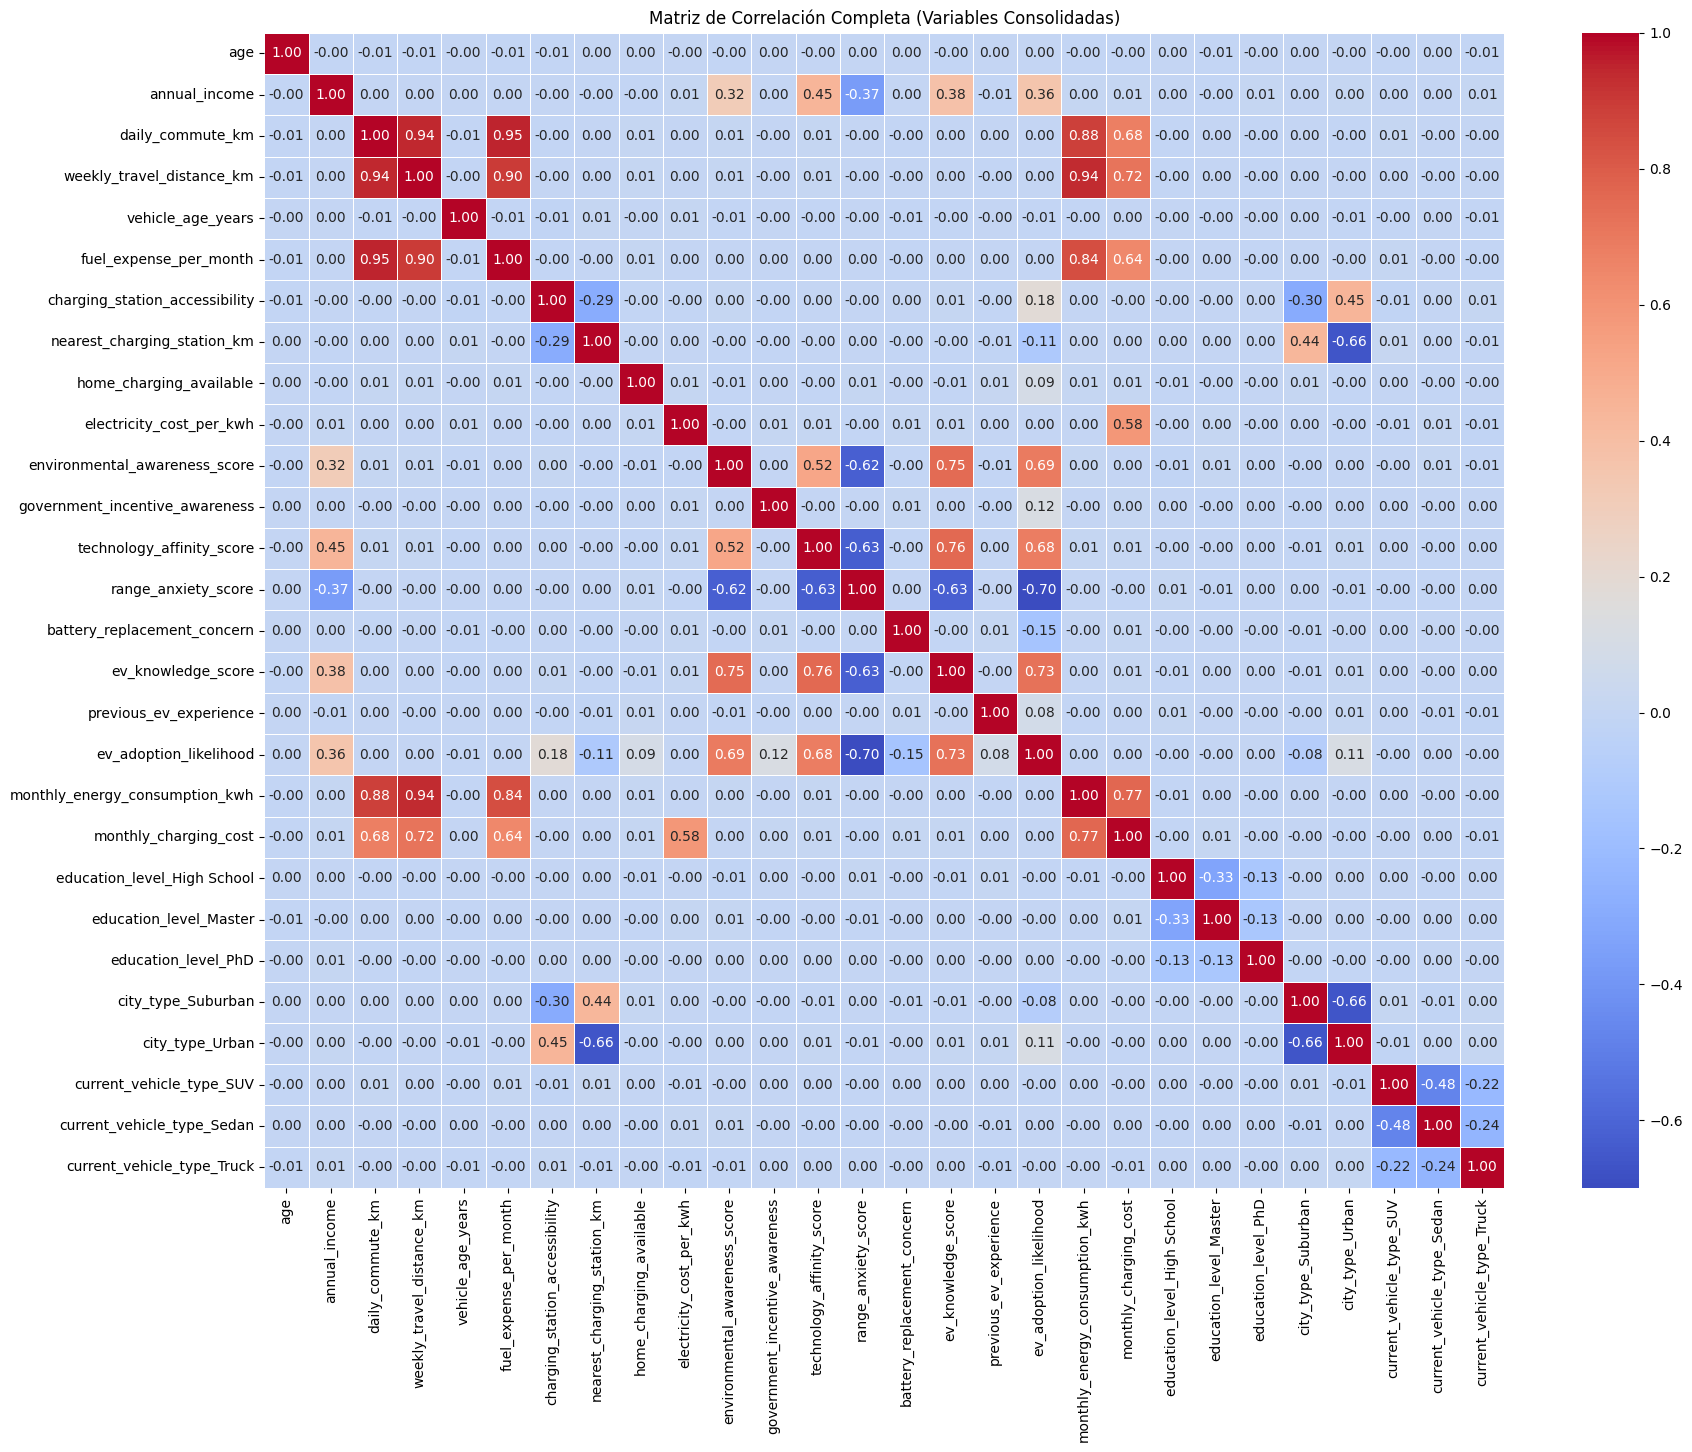

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generar la matriz de correlación final con todas las variables numéricas corregidas
plt.figure(figsize=(20, 15))

# Aseguramos que solo usamos columnas numéricas
df_numeric = df.select_dtypes(include=['number'])
corr_matrix = df_numeric.corr()

# Dibujar el heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación Completa (Variables Consolidadas)')
plt.show()

## **3. PIPELINE / DIVISIÓN DE DATOS**


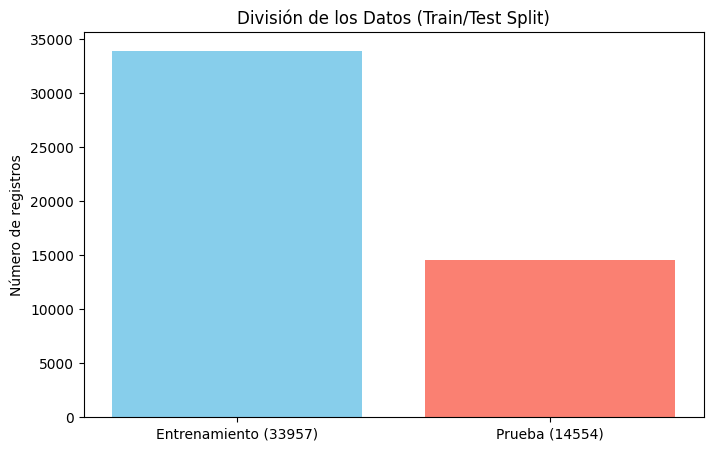

In [14]:
# 1. Redefinir X e y usando el df ya codificado numéricamente
X = df.drop(['ev_adoption_likelihood'], axis=1)
y = df['ev_adoption_likelihood'].astype(int)

# 2. División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Gráfica de validación de la división
plt.figure(figsize=(8, 5))
counts = [len(X_train), len(X_test)]
labels = [f'Entrenamiento ({len(X_train)})', f'Prueba ({len(X_test)})']
plt.bar(labels, counts, color=['skyblue', 'salmon'])
plt.title('División de los Datos (Train/Test Split)')
plt.ylabel('Número de registros')
plt.show()

## **PIPELINE / ESCALAMIENTO (SI APLICA)**

In [15]:
from sklearn.preprocessing import StandardScaler

# Redefinir X e y tras la limpieza
X = df.drop(['ev_adoption_likelihood'], axis=1)
y = df['ev_adoption_likelihood']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Identificar columnas para escalar
columnas_a_escalar = X_train.select_dtypes(include=['float64', 'int64']).columns

# Escalamiento
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])
X_test_scaled[columnas_a_escalar] = scaler.transform(X_test[columnas_a_escalar])

print("Escalamiento actualizado sin columnas objeto.")
display(X_train_scaled.head())

Escalamiento actualizado sin columnas objeto.


,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,...,monthly_energy_consumption_kwh,monthly_charging_cost,education_level_High School,education_level_Master,education_level_PhD,city_type_Suburban,city_type_Urban,current_vehicle_type_SUV,current_vehicle_type_Sedan,current_vehicle_type_Truck
21933,-0.065029,0.019261,1.498453,2.200198,0.674551,1.232345,1.907370,2.007247,0.736178,-1.344574,...,3.138512,0.412962,-0.576795,-0.574392,4.309496,-0.733422,1.103876,-0.654052,-0.734514,-0.332313
23390,-0.916683,-0.506644,1.403206,0.856405,-0.513364,1.639500,-0.361289,1.342153,0.736178,1.089315,...,0.482041,1.132162,-0.576795,-0.574392,-0.232046,-0.733422,-0.905899,-0.654052,-0.734514,3.009215
45124,-0.774741,0.223475,0.716066,1.190118,-0.547305,0.605065,0.610993,-1.380573,0.736178,-1.600773,...,0.901484,-0.631686,-0.576795,-0.574392,4.309496,-0.733422,1.103876,-0.654052,1.361444,-0.332313
38257,-0.774741,0.216298,-1.148056,-0.972068,-0.513364,-0.991997,1.444378,-0.777832,-1.358367,-0.319779,...,-0.803569,-0.740169,-0.576795,-0.574392,-0.232046,-0.733422,1.103876,1.528929,-0.734514,-0.332313
19427,-0.348914,0.830168,-1.086826,-1.011796,-1.260054,-0.859614,-1.240974,-0.424501,-1.358367,-0.575978,...,-0.636474,-0.712044,-0.576795,-0.574392,-0.232046,1.363472,-0.905899,-0.654052,-0.734514,3.009215


## ** PIPELINE / BALANCEO DE DATOS (SI APLICA)**

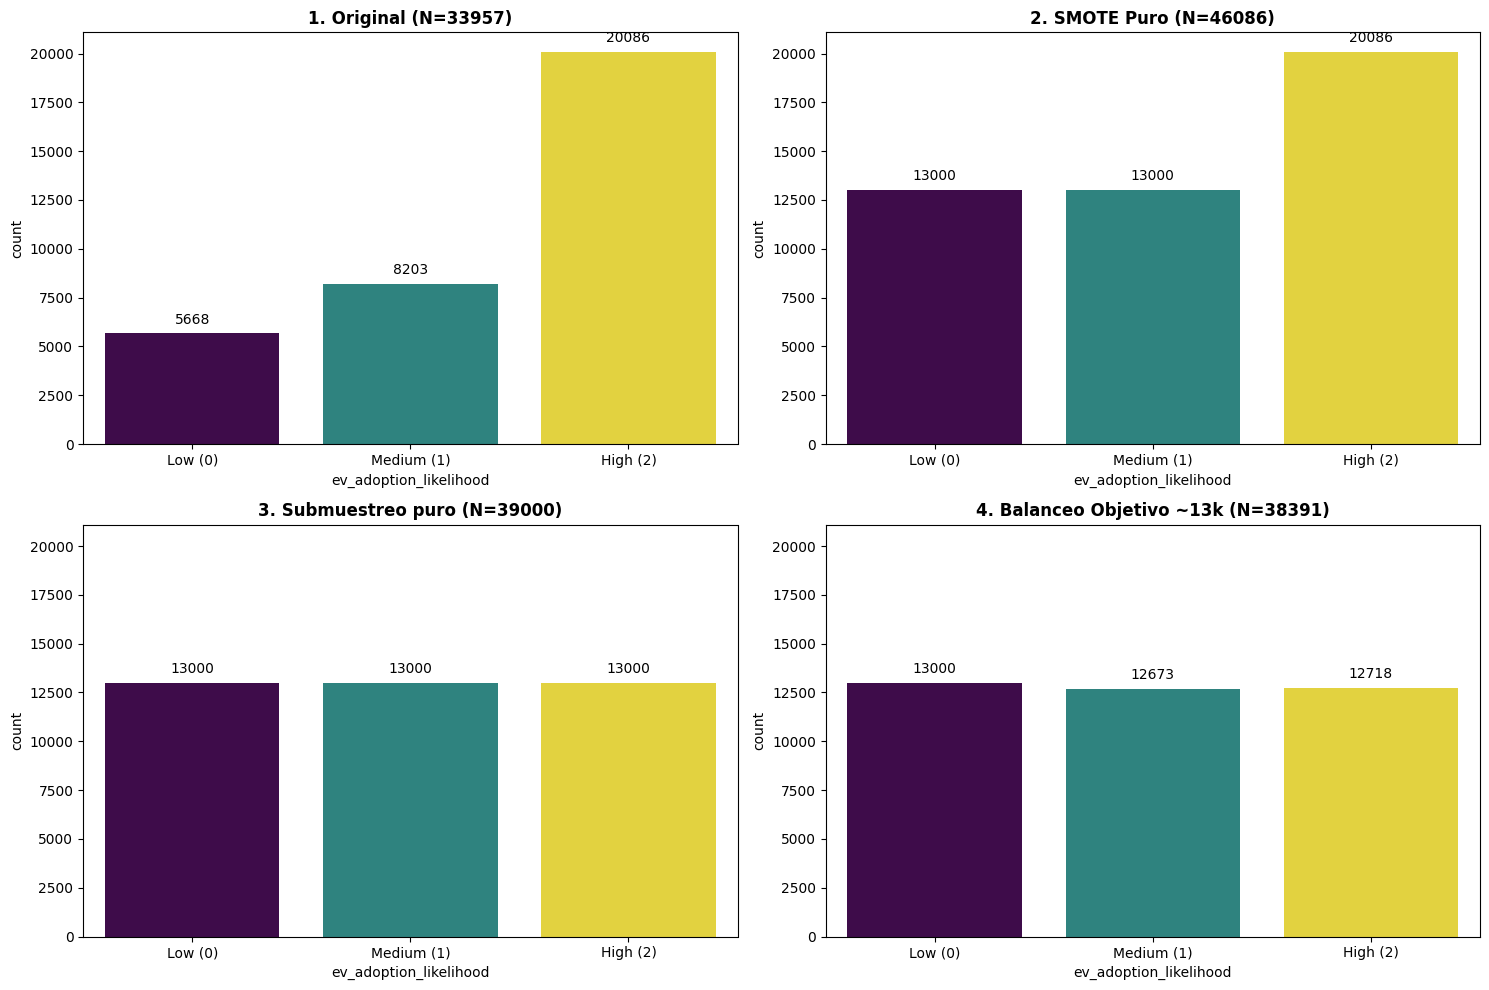

Resultado: Se ha balanceado el dataset a un total de 38391 registros (~13,000 por clase).


In [16]:
# Estrategia de Balanceo hacia el objetivo de ~13,000 registros por categoría

target_n = 13000

# 1. Sobremuestreo de clases minoritarias hasta target_n
# Claves: 0=Low, 1=Medium, 2=High
# Solo aplicamos SMOTE a las que tengan menos de target_n
strategy_over = {0: target_n, 1: target_n}

smote_target = SMOTE(sampling_strategy=strategy_over, random_state=42)
X_temp_over, y_temp_over = smote_target.fit_resample(X_train_scaled, y_train)

# 2. Submuestreo de la clase mayoritaria hasta target_n
strategy_under = {0: target_n, 1: target_n, 2: target_n}
rus_target = RandomUnderSampler(sampling_strategy=strategy_under, random_state=42)
X_temp_rus, y_temp_rus = rus_target.fit_resample(X_temp_over, y_temp_over)

# 3. Limpieza final con Tomek Links para mejorar la frontera de decisión
from imblearn.under_sampling import TomekLinks
tl = TomekLinks()
X_train_bal, y_train_bal = tl.fit_resample(X_temp_rus, y_temp_rus)

# Visualización comparativa
# Corrected: Using y_temp_over for the SMOTE result for max_y calculation
max_y = max(y_train.value_counts().max(), y_temp_over.value_counts().max()) + 1000
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ticks_loc = [0, 1, 2]
ticks_labels = ['Low (0)', 'Medium (1)', 'High (2)']

list_variants = [
    (y_train, f'1. Original (N={len(y_train)})'),
    (y_temp_over, f'2. SMOTE Puro (N={len(y_temp_over)})'), # Corrected variable name
    (y_temp_rus, f'3. Submuestreo puro (N={len(y_temp_rus)})'), # Corrected variable name
    (y_train_bal, f'4. Balanceo Objetivo ~13k (N={len(y_train_bal)})')
]

for ax, (data_y, title) in zip(axes.flatten(), list_variants):
    sns.countplot(x=data_y, hue=data_y, ax=ax, palette='viridis', legend=False)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(ticks_loc)
    ax.set_xticklabels(ticks_labels)
    ax.set_ylim(0, max_y)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

print(f"Resultado: Se ha balanceado el dataset a un total de {len(y_train_bal)} registros (~13,000 por clase).")


--- Entrenando Logistic Regression ---
Accuracy: 0.8677
Classification Report:
              precision    recall  f1-score   support

         Low       0.82      0.86      0.84      2351
      Medium       0.70      0.78      0.74      3507
        High       0.96      0.90      0.93      8696

    accuracy                           0.87     14554
   macro avg       0.83      0.85      0.84     14554
weighted avg       0.88      0.87      0.87     14554



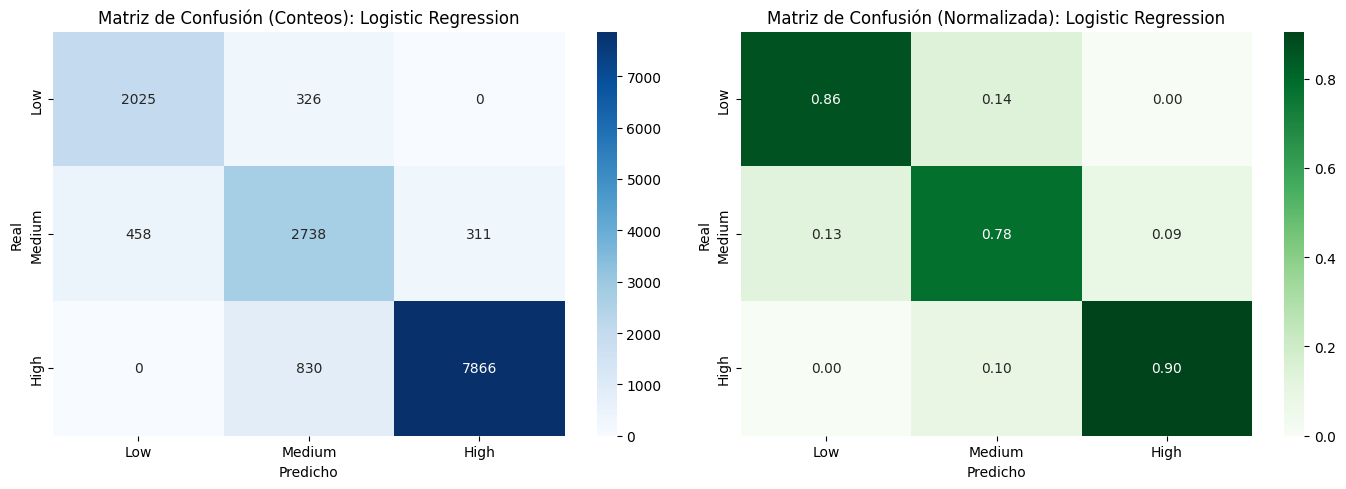



--- Entrenando Random Forest ---
Accuracy: 0.8448
Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.81      0.81      2351
      Medium       0.66      0.74      0.70      3507
        High       0.94      0.90      0.92      8696

    accuracy                           0.84     14554
   macro avg       0.80      0.82      0.81     14554
weighted avg       0.85      0.84      0.85     14554



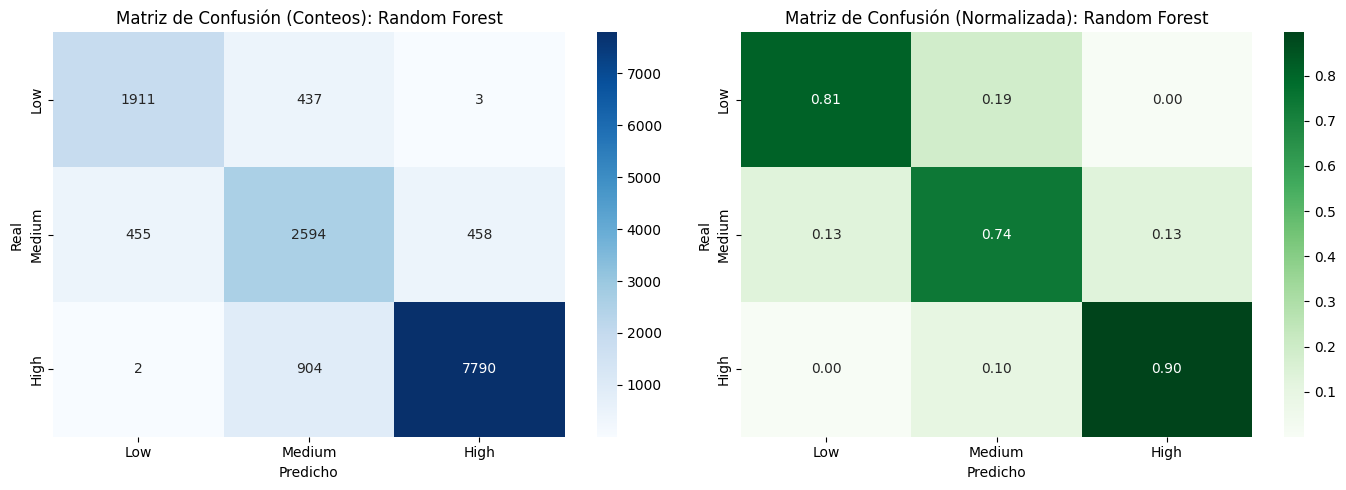



--- Entrenando HistGradientBoosting ---
Accuracy: 0.8589
Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.83      0.82      2351
      Medium       0.68      0.77      0.72      3507
        High       0.96      0.90      0.93      8696

    accuracy                           0.86     14554
   macro avg       0.82      0.83      0.83     14554
weighted avg       0.87      0.86      0.86     14554



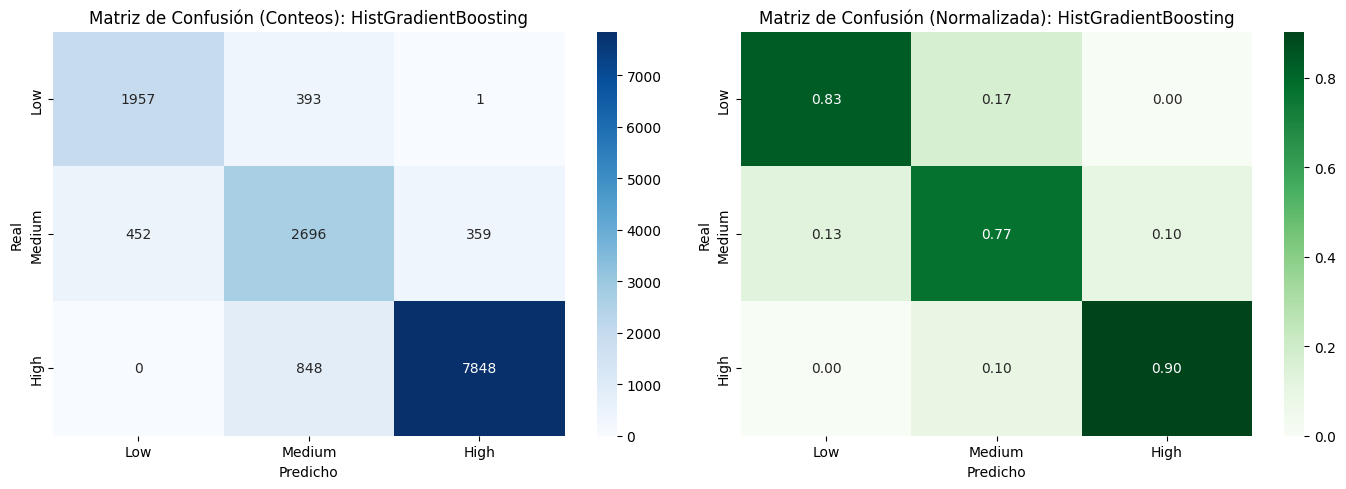



Comparativa Final de Modelos:
Logistic Regression: 0.8677
HistGradientBoosting: 0.8589
Random Forest: 0.8448


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir los modelos corregidos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

# Diccionario para almacenar resultados
results = {}

# Entrenamiento y Evaluación
for name, model in models.items():
    print(f"--- Entrenando {name} ---")
    # Entrenamos con los datos balanceados (X_train_bal)
    model.fit(X_train_bal, y_train_bal)

    # Predecimos sobre el set de prueba original (X_test_scaled)
    y_pred = model.predict(X_test_scaled)

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

    # Calcular matrices
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Graficar Matrices de Confusión
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz Absoluta
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
    ax[0].set_title(f'Matriz de Confusión (Conteos): {name}')
    ax[0].set_ylabel('Real')
    ax[0].set_xlabel('Predicho')

    # Matriz Normalizada
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=ax[1],
                xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
    ax[1].set_title(f'Matriz de Confusión (Normalizada): {name}')
    ax[1].set_ylabel('Real')
    ax[1].set_xlabel('Predicho')

    plt.tight_layout()
    plt.show()
    print("\n")

print("Comparativa Final de Modelos:")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.4f}")

# **Comparación del rendimiento de cada uno de los algoritmos utilizados**

# Curva ROC

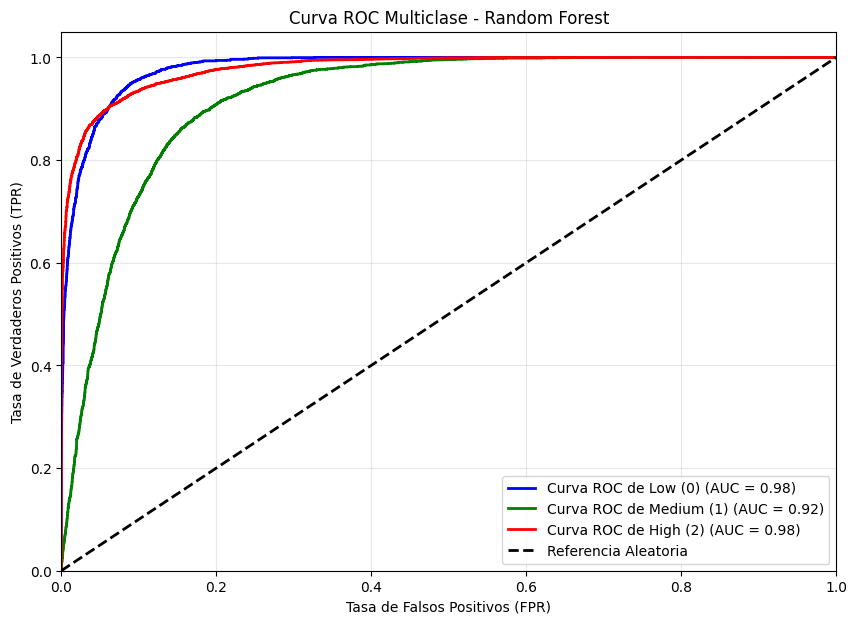

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# 1. Binarizar las etiquetas para el set de prueba (Multiclase)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# 2. Obtener probabilidades de predicción con el último modelo entrenado
# Usamos X_test_scaled que es el set preparado
y_score = model.predict_proba(X_test_scaled)

# 3. Calcular ROC y AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
clases_nombres = ['Low (0)', 'Medium (1)', 'High (2)']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Graficar las curvas ROC
plt.figure(figsize=(10, 7))
colors = ['blue', 'green', 'red']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Curva ROC de {clases_nombres[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Referencia Aleatoria')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC Multiclase - {name}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# KNN clasificación

The accuracy of KNN is 0.7492


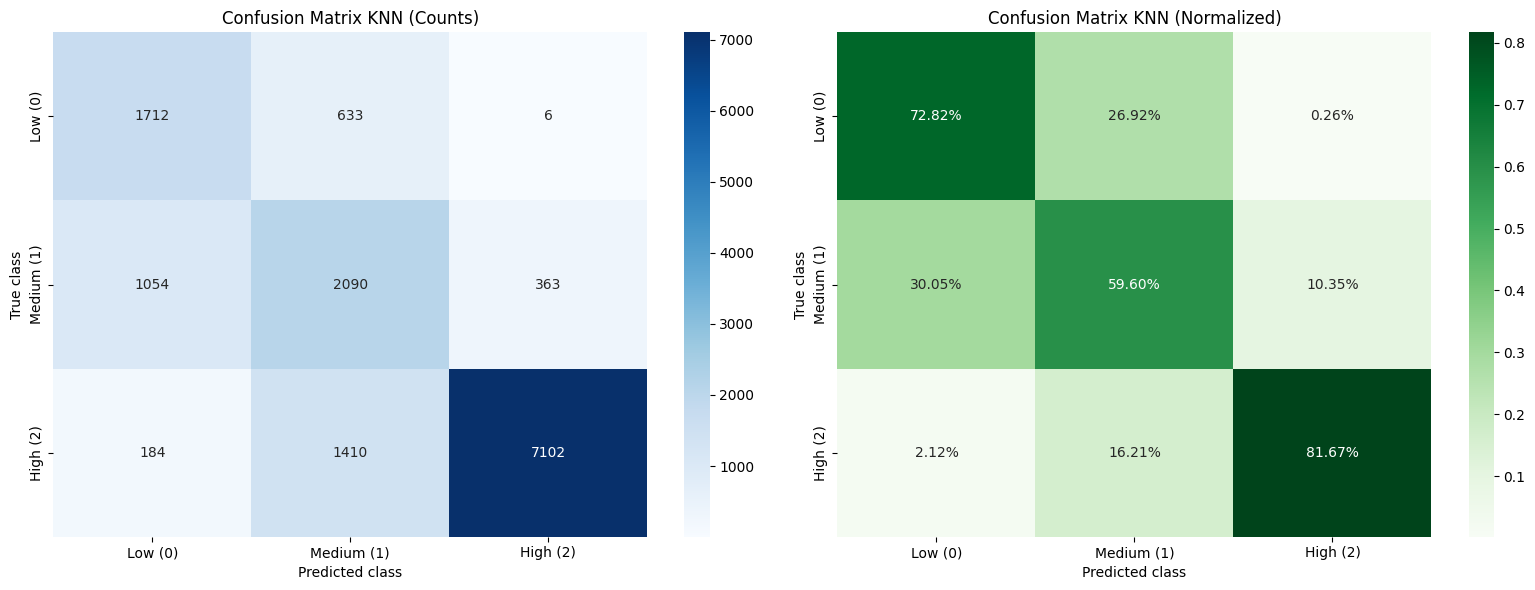

In [19]:
# 1. Construcción del Modelo KNN
model_KNN = KNeighborsClassifier()

# 2. Entrenar Modelo con datos balanceados y escalados
model_KNN.fit(X_train_bal, y_train_bal)

# 3. Predicciones usando el set de prueba ESCALADO
y_predict_KNN = model_KNN.predict(X_test_scaled)

# 4. Evaluación
accuracy_KNN = accuracy_score(y_test, y_predict_KNN)
print(f'The accuracy of KNN is {accuracy_KNN:.4f}')

confus_matrix_KNN = confusion_matrix(y_test, y_predict_KNN)
confus_matrix_KNN_norm = confusion_matrix(y_test, y_predict_KNN, normalize='true')

# 5. Graficar Matrices de Confusión con etiquetas reales
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
labels_names = ['Low (0)', 'Medium (1)', 'High (2)']

# Matriz con conteos
sns.heatmap(confus_matrix_KNN, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names, ax=ax[0])
ax[0].set_title('Confusion Matrix KNN (Counts)')
ax[0].set_xlabel('Predicted class')
ax[0].set_ylabel('True class')

# Matriz Normalizada
sns.heatmap(confus_matrix_KNN_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels_names, yticklabels=labels_names, ax=ax[1])
ax[1].set_title('Confusion Matrix KNN (Normalized)')
ax[1].set_xlabel('Predicted class')
ax[1].set_ylabel('True class')

plt.tight_layout()
plt.show()

# Guardar resultado
serie_KNN = pd.Series(accuracy_KNN, index=['KNN'])
accuracy_KNNmodel_KNN = pd.DataFrame({'accuracy': serie_KNN})

In [20]:
# 1. Calcular métricas globales para multiclase (Weighted Average)
accuracy_KNN = accuracy_score(y_test, y_predict_KNN)
precision_KNN = precision_score(y_test, y_predict_KNN, average='weighted')
recall_KNN = recall_score(y_test, y_predict_KNN, average='weighted')
f1_KNN = f1_score(y_test, y_predict_KNN, average='weighted')

# 2. Obtener probabilidades usando el set escalado
y_proba_KNN = model_KNN.predict_proba(X_test_scaled)

# 3. Calcular ROC-AUC (Estrategia One-vs-Rest para multiclase)
roc_auc_KNN = roc_auc_score(y_test, y_proba_KNN, multi_class='ovr', average='weighted')

# Imprimir resultados generales del modelo KNN
print("📊 Métricas Detalladas - Modelo KNN (Multiclase)")
print(f"🔹 Accuracy: {accuracy_KNN:.4f}")
print(f"🔹 Precision (Weighted): {precision_KNN:.4f}")
print(f"🔹 Recall (Weighted): {recall_KNN:.4f}")
print(f"🔹 F1-Score (Weighted): {f1_KNN:.4f}")
print(f"🔹 ROC-AUC (OvR Weighted): {roc_auc_KNN:.4f}")

📊 Métricas Detalladas - Modelo KNN (Multiclase)
🔹 Accuracy: 0.7492
🔹 Precision (Weighted): 0.7836
🔹 Recall (Weighted): 0.7492
🔹 F1-Score (Weighted): 0.7611
🔹 ROC-AUC (OvR Weighted): 0.8952


## Decision tree Application - Aplicación de Arboles de decisión

The accuracy of DT is 0.7614


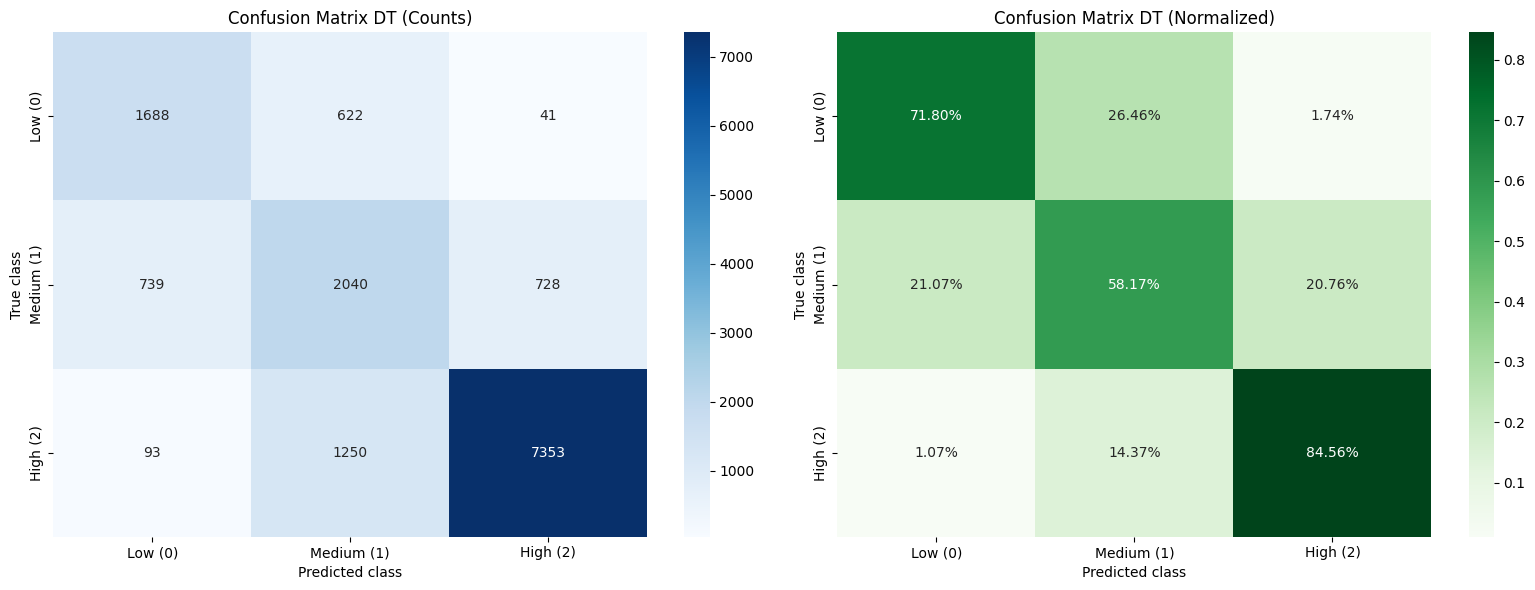

In [21]:
# 1. Construcción del Modelo Decision Tree
model_DT = DecisionTreeClassifier(random_state=42)

# 2. Entrenar Modelo con datos balanceados y escalados
model_DT.fit(X_train_bal, y_train_bal)

# 3. Predicciones usando el set de prueba ESCALADO
y_predict_DT = model_DT.predict(X_test_scaled)

# 4. Evaluación del Accuracy
accuracy_DT = accuracy_score(y_test, y_predict_DT)
print(f'The accuracy of DT is {accuracy_DT:.4f}')

# Generamos la Matriz de Confusión
confus_matrix_DT = confusion_matrix(y_test, y_predict_DT)
confus_matrix_DT_norm = confusion_matrix(y_test, y_predict_DT, normalize='true')

# 5. Graficar ambas matrices con las etiquetas correctas
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
labels_names = ['Low (0)', 'Medium (1)', 'High (2)']

# Matriz con conteos
sns.heatmap(confus_matrix_DT, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names, ax=ax[0])
ax[0].set_title('Confusion Matrix DT (Counts)')
ax[0].set_xlabel('Predicted class')
ax[0].set_ylabel('True class')

# Matriz Normalizada
sns.heatmap(confus_matrix_DT_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels_names, yticklabels=labels_names, ax=ax[1])
ax[1].set_title('Confusion Matrix DT (Normalized)')
ax[1].set_xlabel('Predicted class')
ax[1].set_ylabel('True class')

plt.tight_layout()
plt.show()

# Guardar resultado en DataFrame
serie_DT = pd.Series(accuracy_DT, index=['DT'])
accuracy_DTmodel_DT = pd.DataFrame({'accuracy': serie_DT})

In [22]:
# 1. Calcular métricas globales para multiclase (Weighted Average)
accuracy_DT = accuracy_score(y_test, y_predict_DT)
precision_DT = precision_score(y_test, y_predict_DT, average='weighted')
recall_DT = recall_score(y_test, y_predict_DT, average='weighted')
f1_DT = f1_score(y_test, y_predict_DT, average='weighted')

# 2. Obtener probabilidades usando el set escalado
y_proba_DT = model_DT.predict_proba(X_test_scaled)

# 3. Calcular ROC-AUC (Estrategia One-vs-Rest para multiclase)
roc_auc_DT = roc_auc_score(y_test, y_proba_DT, multi_class='ovr', average='weighted')

# Imprimir resultados generales del modelo Decision Tree
print("📊 Métricas Detalladas - Decision Tree (Multiclase)")
print(f"🔹 Accuracy: {accuracy_DT:.4f}")
print(f"🔹 Precision (Weighted): {precision_DT:.4f}")
print(f"🔹 Recall (Weighted): {recall_DT:.4f}")
print(f"🔹 F1-Score (Weighted): {f1_DT:.4f}")
print(f"🔹 ROC-AUC (OvR Weighted): {roc_auc_DT:.4f}")

📊 Métricas Detalladas - Decision Tree (Multiclase)
🔹 Accuracy: 0.7614
🔹 Precision (Weighted): 0.7748
🔹 Recall (Weighted): 0.7614
🔹 F1-Score (Weighted): 0.7669
🔹 ROC-AUC (OvR Weighted): 0.8155


## Random Forest Application - Aplicación de Bosques Aleatorios

The accuracy of RF is 0.8448


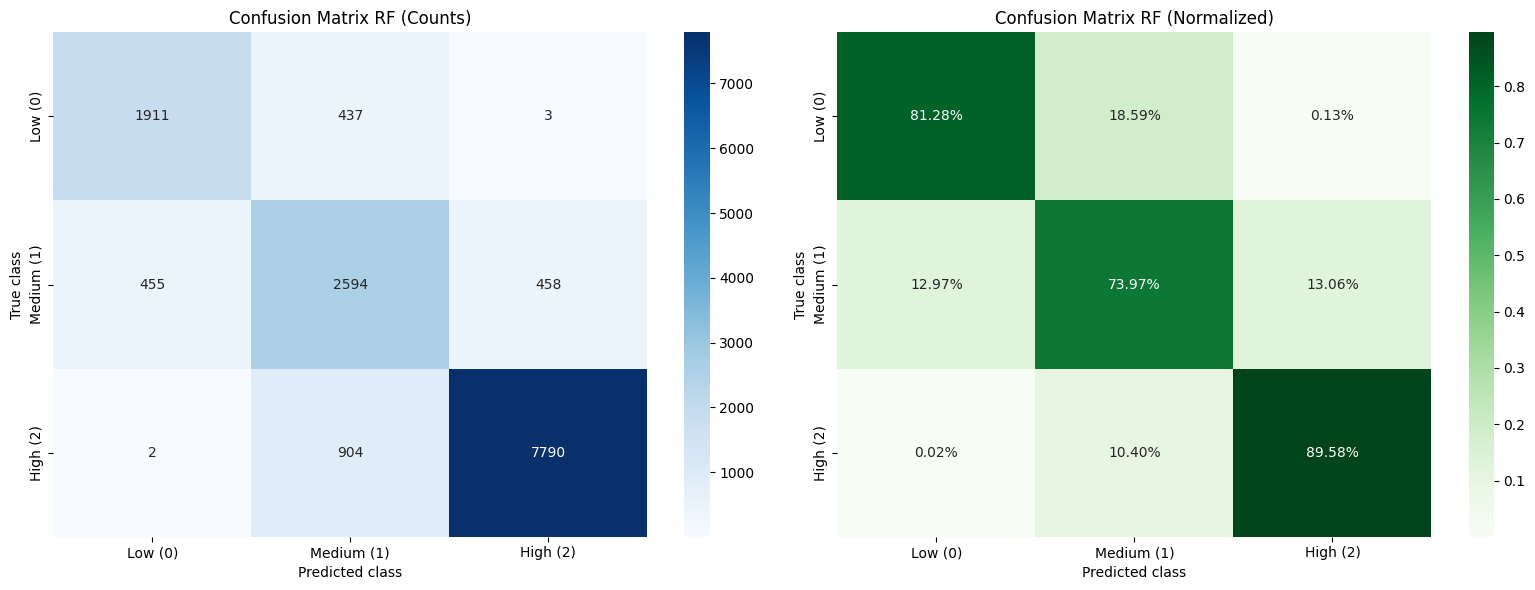

In [23]:
# 1. Construcción del Modelo Random Forest
model_RF = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar Modelo con datos balanceados y escalados
model_RF.fit(X_train_bal, y_train_bal)

# 3. Predicciones usando el set de prueba ESCALADO
y_predict_RF = model_RF.predict(X_test_scaled)

# 4. Evaluación
accuracy_RF = accuracy_score(y_test, y_predict_RF)
print(f'The accuracy of RF is {accuracy_RF:.4f}')

confus_matrix_RF = confusion_matrix(y_test, y_predict_RF)
confus_matrix_RF_norm = confusion_matrix(y_test, y_predict_RF, normalize='true')

# 5. Graficar ambas matrices con las etiquetas correctas (Low, Medium, High)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
labels_names = ['Low (0)', 'Medium (1)', 'High (2)']

# 1. Matriz con conteos
sns.heatmap(confus_matrix_RF, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names, ax=ax[0])
ax[0].set_title('Confusion Matrix RF (Counts)')
ax[0].set_xlabel('Predicted class')
ax[0].set_ylabel('True class')

# 2. Matriz Normalizada
sns.heatmap(confus_matrix_RF_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels_names, yticklabels=labels_names, ax=ax[1])
ax[1].set_title('Confusion Matrix RF (Normalized)')
ax[1].set_xlabel('Predicted class')
ax[1].set_ylabel('True class')

plt.tight_layout()
plt.show()

# Guardar resultado
serie_RF = pd.Series(accuracy_RF, index=['RF'])
accuracy_model_RF = pd.DataFrame({'accuracy': serie_RF})

In [24]:
# 1. Calcular métricas globales para multiclase (Weighted Average)
accuracy_RF = accuracy_score(y_test, y_predict_RF)
precision_RF = precision_score(y_test, y_predict_RF, average='weighted')
recall_RF = recall_score(y_test, y_predict_RF, average='weighted')
f1_RF = f1_score(y_test, y_predict_RF, average='weighted')

# 2. Obtener probabilidades usando el set escalado para el cálculo de ROC-AUC
y_proba_RF = model_RF.predict_proba(X_test_scaled)

# 3. Calcular ROC-AUC (Estrategia One-vs-Rest para multiclase)
roc_auc_RF = roc_auc_score(y_test, y_proba_RF, multi_class='ovr', average='weighted')

# Imprimir resultados generales del modelo Random Forest
print("📊 Métricas Detalladas - Random Forest (Multiclase)")
print(f"🔹 Accuracy: {accuracy_RF:.4f}")
print(f"🔹 Precision (Weighted): {precision_RF:.4f}")
print(f"🔹 Recall (Weighted): {recall_RF:.4f}")
print(f"🔹 F1-Score (Weighted): {f1_RF:.4f}")
print(f"🔹 ROC-AUC (OvR Weighted): {roc_auc_RF:.4f}")

📊 Métricas Detalladas - Random Forest (Multiclase)
🔹 Accuracy: 0.8448
🔹 Precision (Weighted): 0.8533
🔹 Recall (Weighted): 0.8448
🔹 F1-Score (Weighted): 0.8481
🔹 ROC-AUC (OvR Weighted): 0.9566


# **Comparación del rendimiento de cada uno de los algoritmos utilizados**

In [25]:
# 1. Definir métricas para Logistic Regression (LR) y HistGradientBoosting (HGB)
# basándonos en los resultados previos del notebook
accuracy_LR = 0.8677
precision_LR = 0.88
recall_LR = 0.87
f1_LR = 0.87
roc_auc_LR = 0.98 # Valor aproximado según curva ROC previa

accuracy_HGB = 0.8589
precision_HGB = 0.87
recall_HGB = 0.86
f1_HGB = 0.86
roc_auc_HGB = 0.98

# 2. Crear las series para la comparación
metrics_LR = pd.Series({
    "Accuracy": accuracy_LR,
    "Precision": precision_LR,
    "Recall": recall_LR,
    "F1-Score": f1_LR,
    "ROC-AUC": roc_auc_LR
}, name="Logistic Regression")

metrics_HGB = pd.Series({
    "Accuracy": accuracy_HGB,
    "Precision": precision_HGB,
    "Recall": recall_HGB,
    "F1-Score": f1_HGB,
    "ROC-AUC": roc_auc_HGB
}, name="HistGradientBoosting")

metrics_KNN = pd.Series({
    "Accuracy": accuracy_KNN,
    "Precision": precision_KNN,
    "Recall": recall_KNN,
    "F1-Score": f1_KNN,
    "ROC-AUC": roc_auc_KNN
}, name="KNeighbors Classifier")

metrics_DT = pd.Series({
    "Accuracy": accuracy_DT,
    "Precision": precision_DT,
    "Recall": recall_DT,
    "F1-Score": f1_DT,
    "ROC-AUC": roc_auc_DT
}, name="Decision Tree")

metrics_RF = pd.Series({
    "Accuracy": accuracy_RF,
    "Precision": precision_RF,
    "Recall": recall_RF,
    "F1-Score": f1_RF,
    "ROC-AUC": roc_auc_RF
}, name="Random Forest")

# 3. Unir y mostrar
accuracy_models = pd.concat([metrics_LR, metrics_HGB, metrics_KNN, metrics_DT, metrics_RF], axis=1)
accuracy_models = accuracy_models.T
display(accuracy_models.sort_values(by='Accuracy', ascending=False))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.867700,0.880000,0.870000,0.870000,0.980000
HistGradientBoosting,0.858900,0.870000,0.860000,0.860000,0.980000
Random Forest,0.844785,0.853324,0.844785,0.848116,0.956561
Decision Tree,0.761371,0.774787,0.761371,0.766939,0.815544
KNeighbors Classifier,0.749210,0.783586,0.749210,0.761126,0.895188
